In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv("Housing.csv")

In [5]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [7]:
data1=data.describe()
data1

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
data.shape
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [11]:
data['basement'] = data['basement'].map({'no':0, 'yes':1})
data['airconditioning'] = data['airconditioning'].map({'no':1, 'yes':1})
data['prefarea'] = data['prefarea'].map({'no':0, 'yes':1})
data['mainroad'] = data['mainroad'].map({'yes':1, 'no':0})
data['guestroom'] = data['guestroom'].map({'no':0, 'yes':1})
data['hotwaterheating'] = data['hotwaterheating'].map({'no':0, 'yes':1})

In [13]:
data['furnishingstatus'] = data['furnishingstatus'].map({'semi-furnished':0, 'unfurnished':-1, "furnished":1})

In [15]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,1,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,1,2,0,-1
541,1767150,2400,3,1,1,0,0,0,0,1,0,0,0
542,1750000,3620,2,1,1,1,0,0,0,1,0,0,-1
543,1750000,2910,3,1,1,0,0,0,0,1,0,0,1


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [19]:
x=data.drop('price',axis=1)
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,1
1,8960,4,4,4,1,0,0,0,1,3,0,1
2,9960,3,2,2,1,0,1,0,1,2,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,1
4,7420,4,1,2,1,1,1,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,1,2,0,-1
541,2400,3,1,1,0,0,0,0,1,0,0,0
542,3620,2,1,1,1,0,0,0,1,0,0,-1
543,2910,3,1,1,0,0,0,0,1,0,0,1


In [21]:
data.fillna

<bound method NDFrame.fillna of         price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0        

In [23]:
y=data.price
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=3,test_size=0.2)

In [51]:
x_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
425,3185,2,1,1,1,0,1,0,1,2,0,1
243,2550,3,1,2,1,0,1,0,1,0,0,1
440,3640,4,1,2,1,0,1,0,1,0,0,-1
279,6360,2,1,1,1,0,0,0,1,0,0,1
395,3600,6,1,2,1,0,0,0,1,1,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
480,3480,3,1,2,0,0,0,0,1,1,0,0
422,3720,2,1,1,0,0,0,0,1,0,0,-1
119,7020,3,1,1,1,0,1,0,1,2,1,0
256,4000,3,1,2,1,0,0,0,1,2,0,1


In [53]:
from sklearn.linear_model import LinearRegression

In [55]:
reg=LinearRegression()

In [57]:
reg.fit(x_train,y_train)

LinearRegression()

In [59]:
y_pred=reg.predict(x_test)
y_pred

array([4704662.69446866, 3915647.49598241, 5749793.01901815,
       6725700.15978951, 4323492.52622843, 4131863.75968074,
       5000879.07721369, 7915096.20917082, 4090266.85770709,
       4177357.9454398 , 2819142.09897917, 6513675.51926254,
       7244987.27938728, 6950826.81880669, 4731235.99750259,
       4135712.9603489 , 2027183.80076887, 5954682.80134197,
       4834563.21164221, 7419328.75663302, 3518480.69158313,
       2697582.70098838, 3641747.56488728, 4010244.06343103,
       8164535.91668008, 5557865.90060755, 5457010.50436028,
       6655528.34061667, 2134135.20243459, 3184825.25834262,
       8483867.25736382, 4319181.72982471, 2384505.86349058,
       6705463.87347895, 7777864.34538738, 4498449.43024264,
       4695890.10321096, 4631099.78147415, 5334459.81114868,
       7468210.12328468, 4453115.6949074 , 5340121.46137951,
       4550668.03132012, 4085025.71757171, 5642494.60906521,
       4692243.60912917, 5803144.07092825, 3758302.75491216,
       5092715.90698385,

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

In [63]:
mse=mean_squared_error(y_test,y_pred)

In [65]:
mse

1204139074025.9246

In [67]:
r2=r2_score(y_test,y_pred)
r2

0.5631191766475054

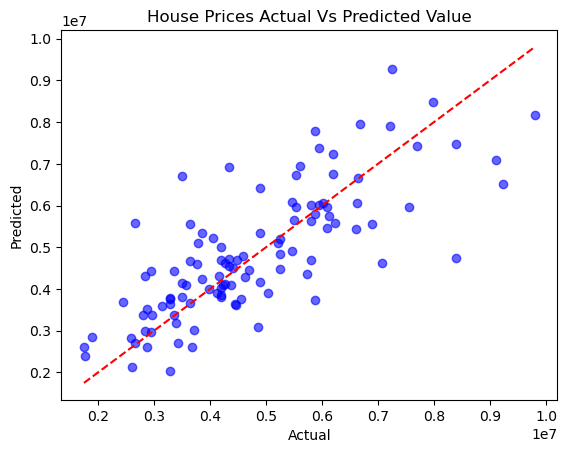

In [69]:
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("House Prices Actual Vs Predicted Value")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--")
plt.show()

In [70]:
reg.intercept_

-240130.19549867697